In [10]:
!unzip "/content/ANPR.v2i.yolov8.zip" -d "/content/dataset"

Archive:  /content/ANPR.v2i.yolov8.zip
 extracting: /content/dataset/valid/images/train533_jpg.rf.cfba4198fae486ddf45c71c249fdd14d.jpg  
 extracting: /content/dataset/train/images/H4886BPE_jpg.rf.b9c26bbde77d72be11674e9ca3dca25e.jpg  
 extracting: /content/dataset/train/images/train043_jpg.rf.1437c0226e52ed9fd1345f76af786bf9.jpg  
 extracting: /content/dataset/train/images/train138_jpg.rf.337e90a5bbbc7c71bfcb1065f30331e0.jpg  
 extracting: /content/dataset/valid/images/train740_jpg.rf.d976c96f69c71f0dbb03d5366e366319.jpg  
 extracting: /content/dataset/train/images/train707_jpg.rf.f31d5d26a171da1891fd33cff33aefcf.jpg  
 extracting: /content/dataset/valid/images/train661_jpg.rf.2704d4a9d0e826c45a0c690af54b47df.jpg  
 extracting: /content/dataset/train/images/train680_jpg.rf.f749fe5262a61eab4e54aaa1189bce06.jpg  
 extracting: /content/dataset/train/images/H6233QB_jpg.rf.6fdc52d31c7cab3fb68b99f9cfa9a141.jpg  
 extracting: /content/dataset/train/images/H4311BI_jpg.rf.f6632588fefc19119da622

In [12]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.2 MB/s eta 0:00:00


In [13]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [14]:
!cat /content/dataset/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['Plat mobil', 'Plat motor']

roboflow:
  workspace: lutfiahs-workspace
  project: anpr-dwklk
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/lutfiahs-workspace/anpr-dwklk/dataset/2

In [15]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pe

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f3b516cddc0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

RESULTS


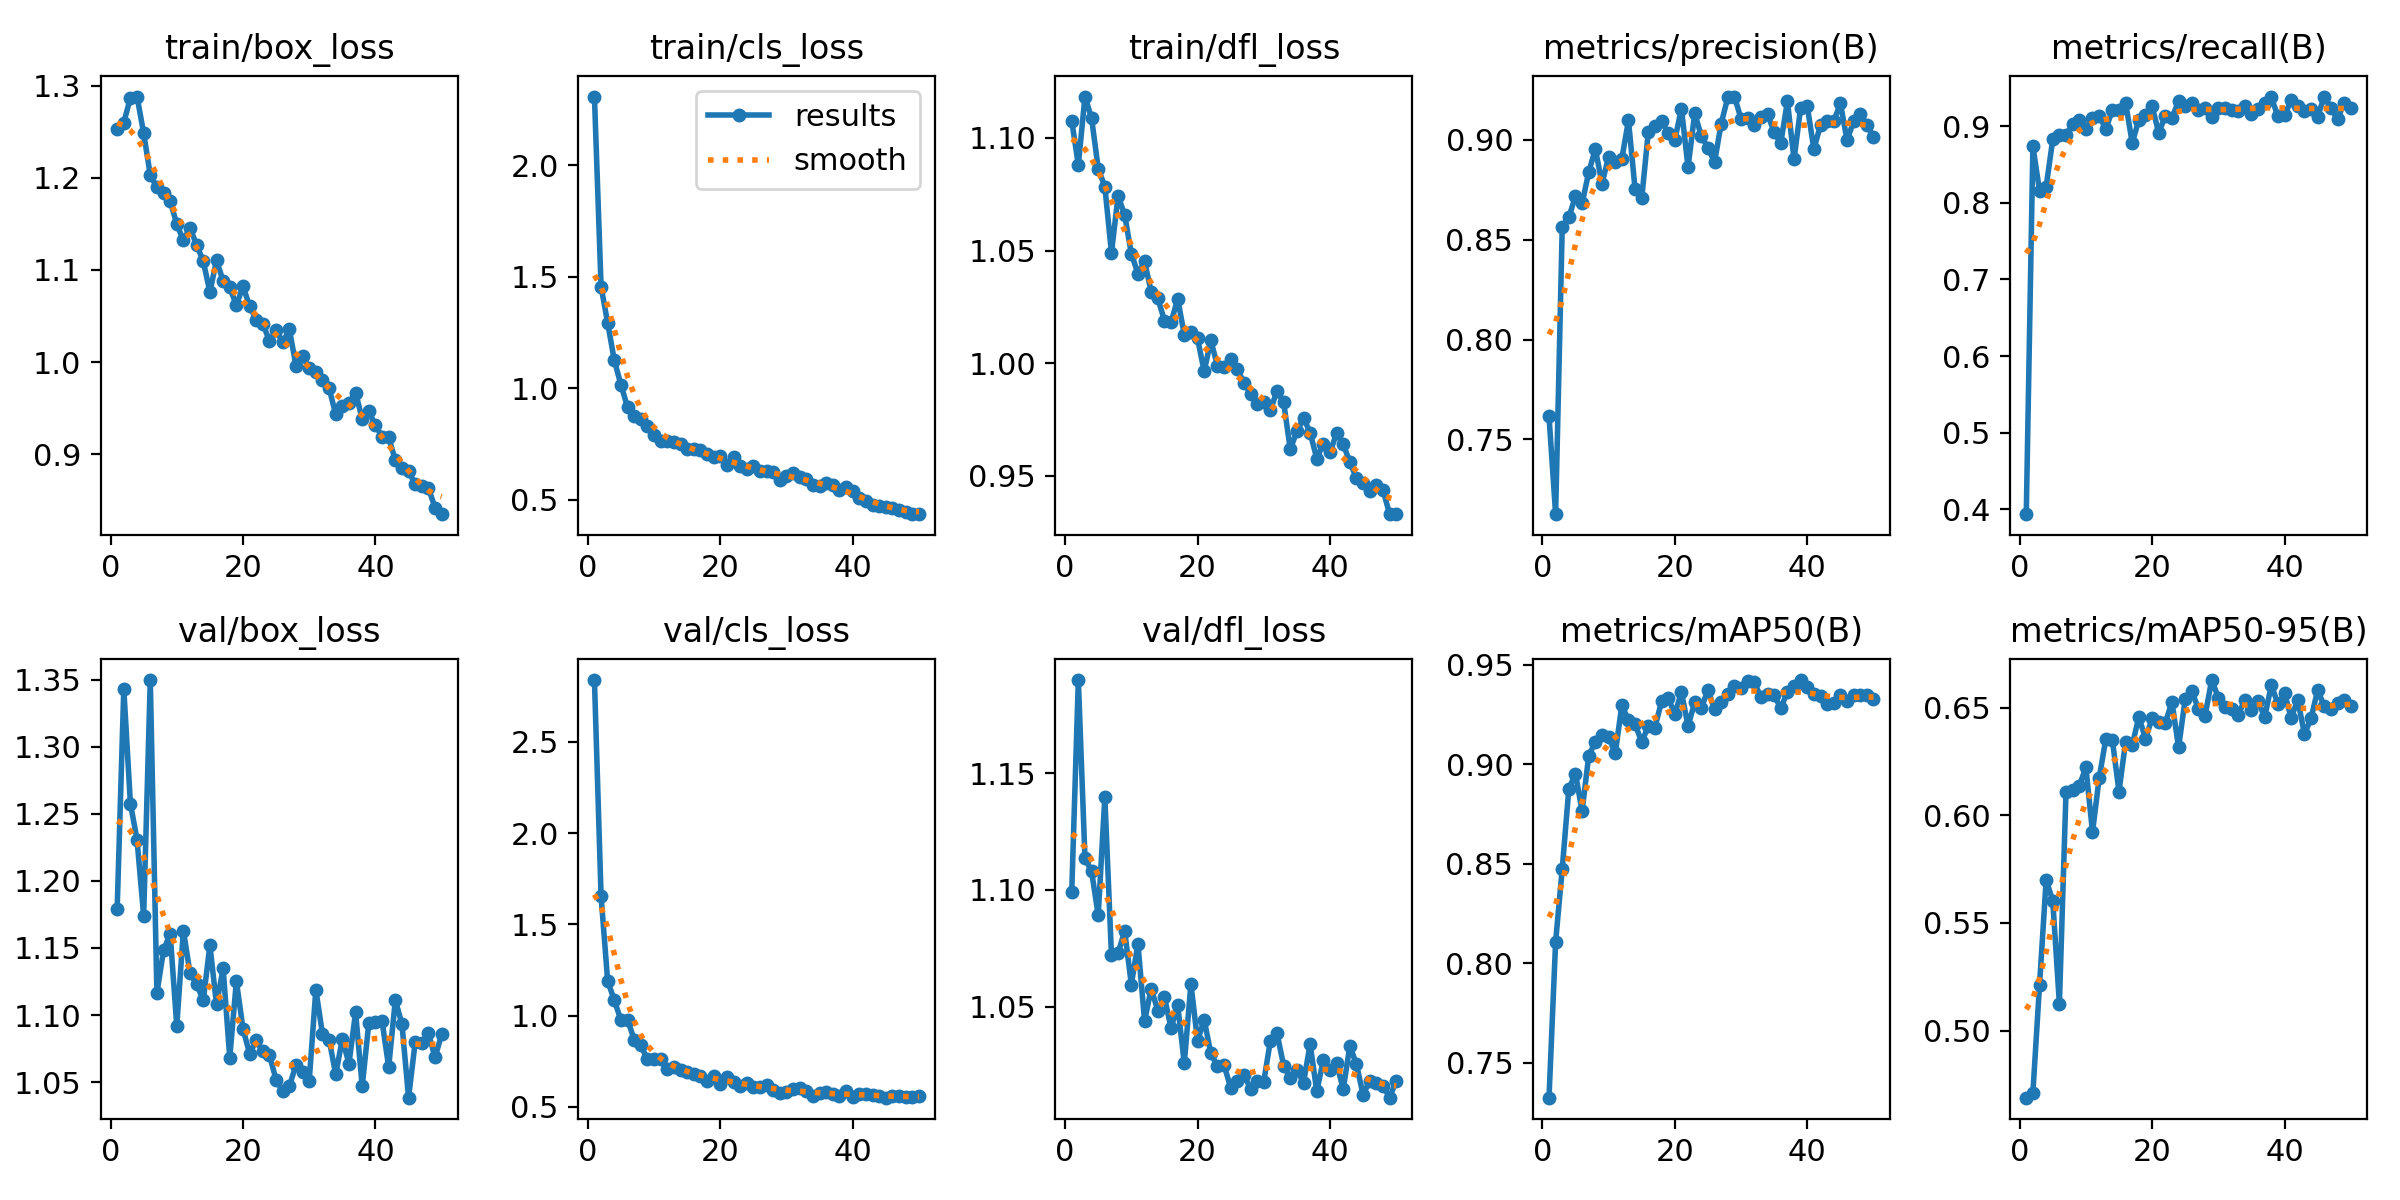

CONFUSION MATRIX


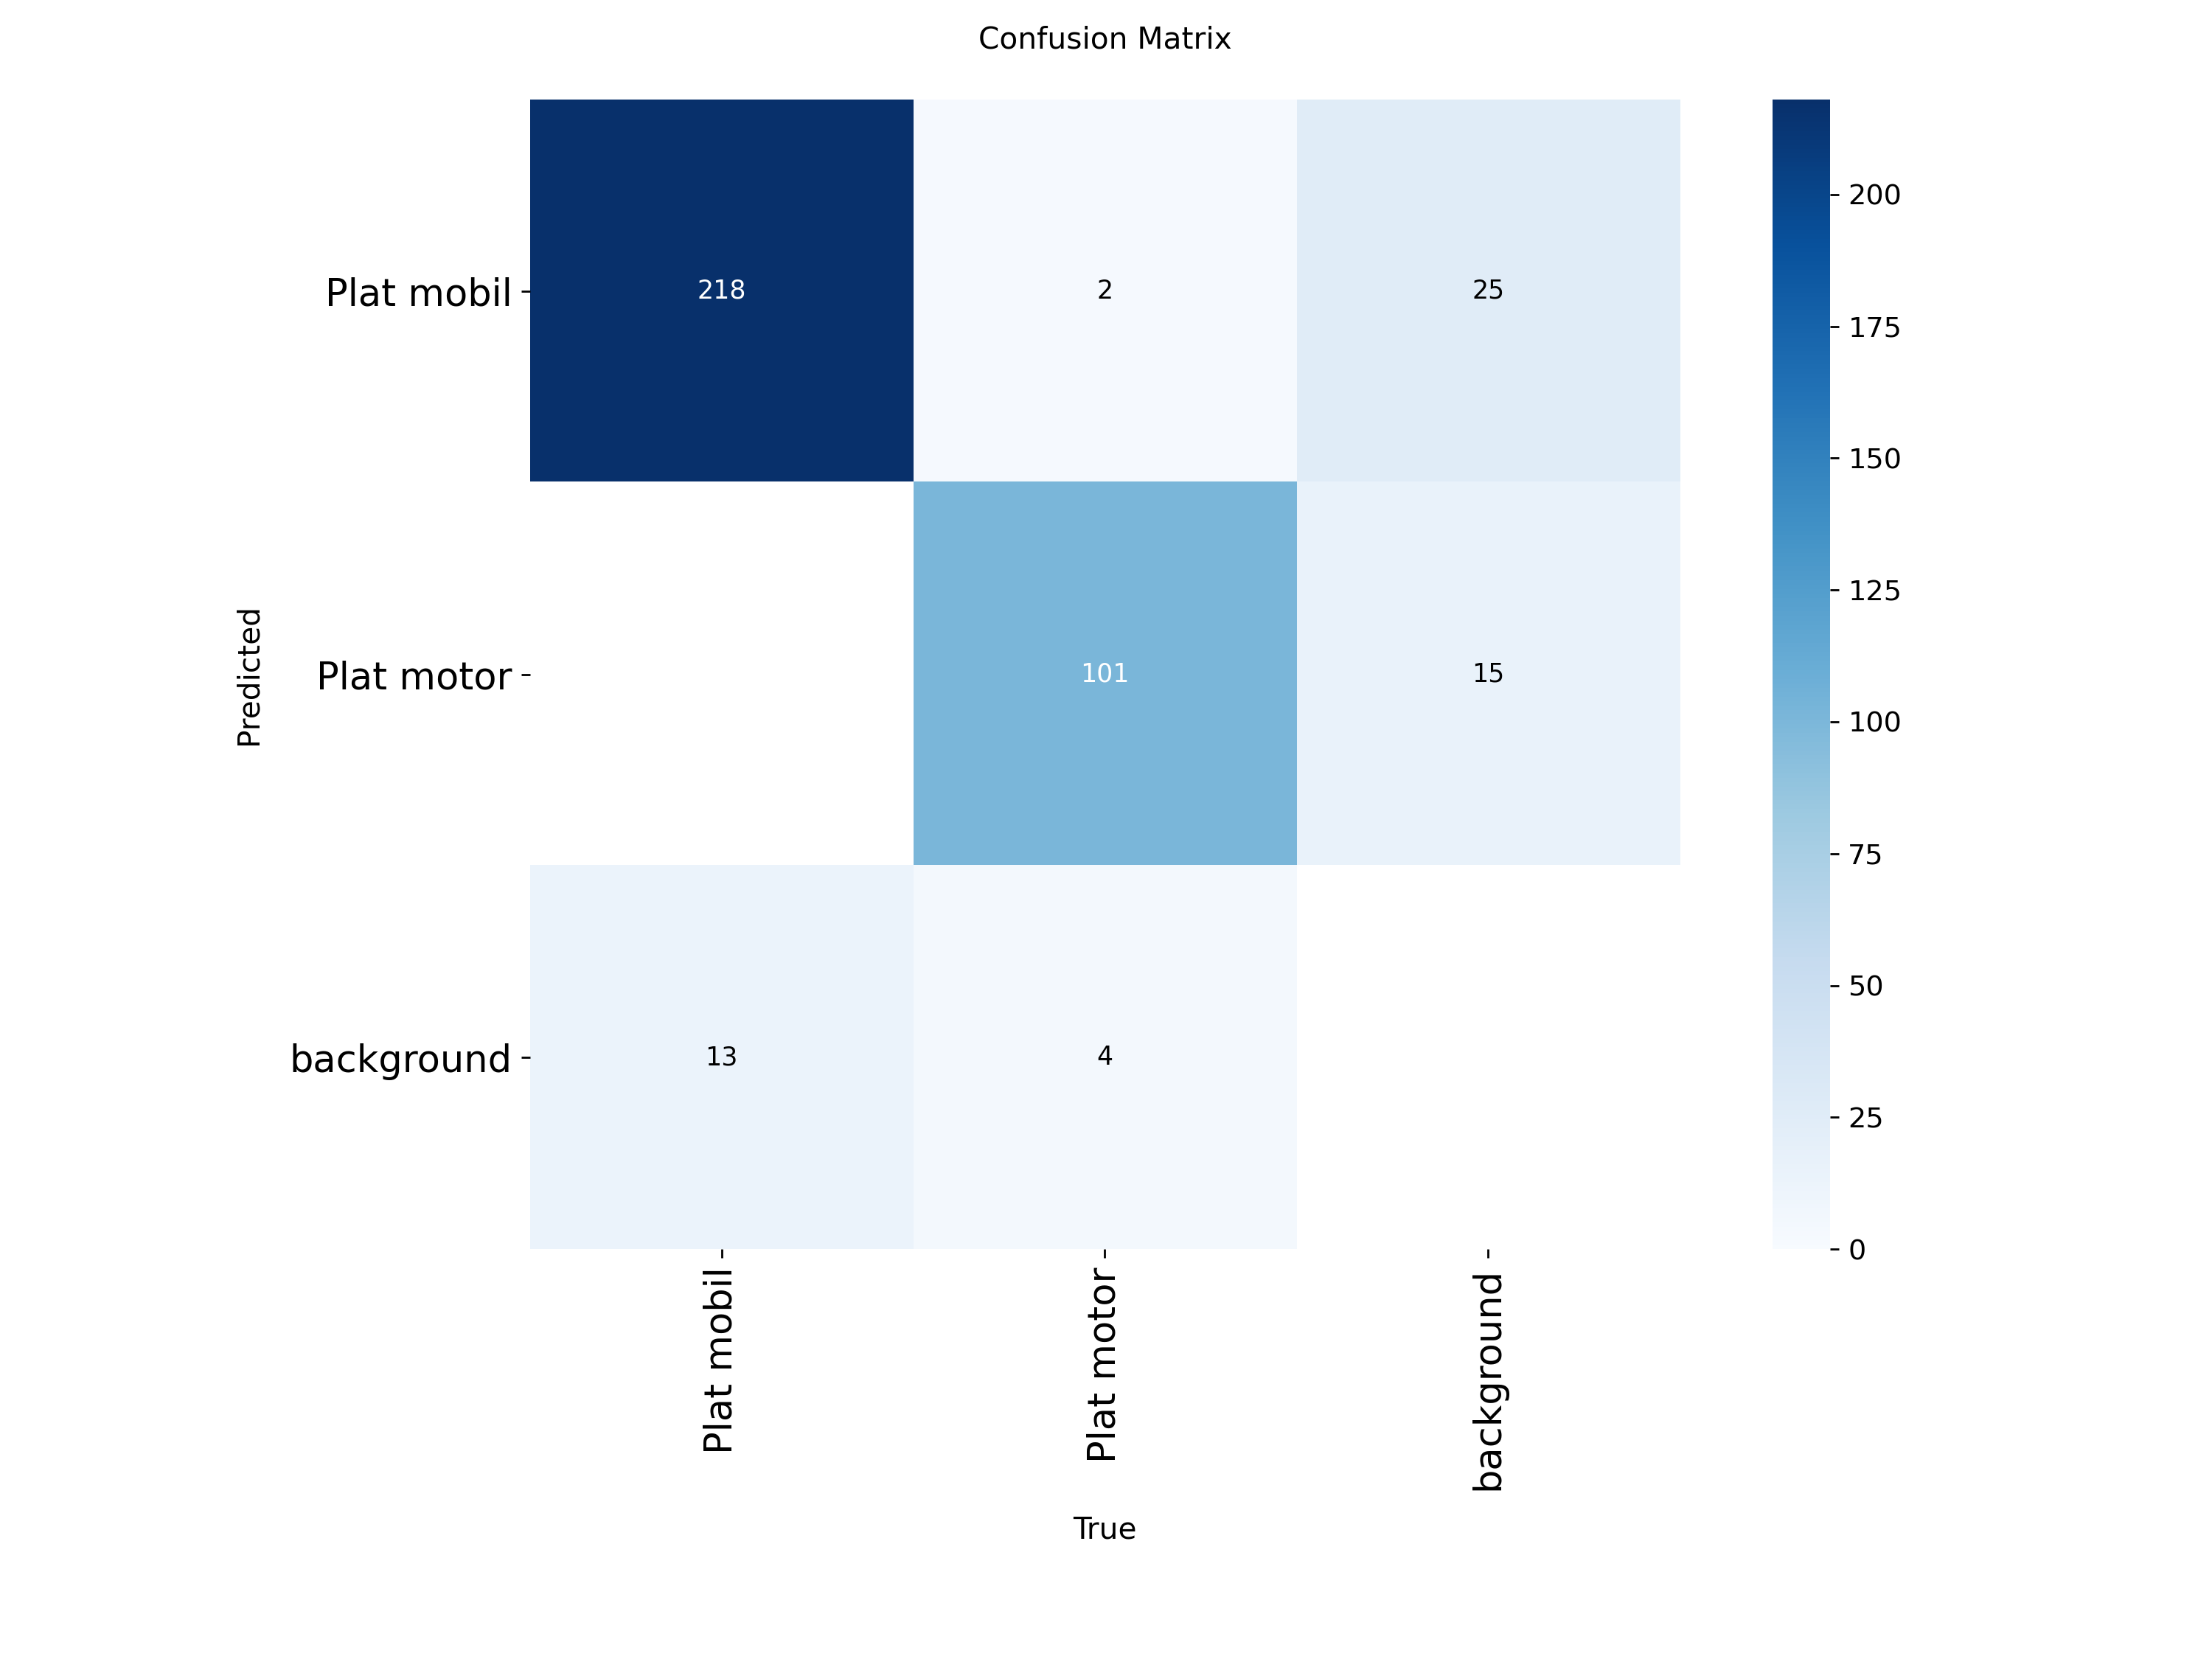

PRECISION-RECALL CURVE


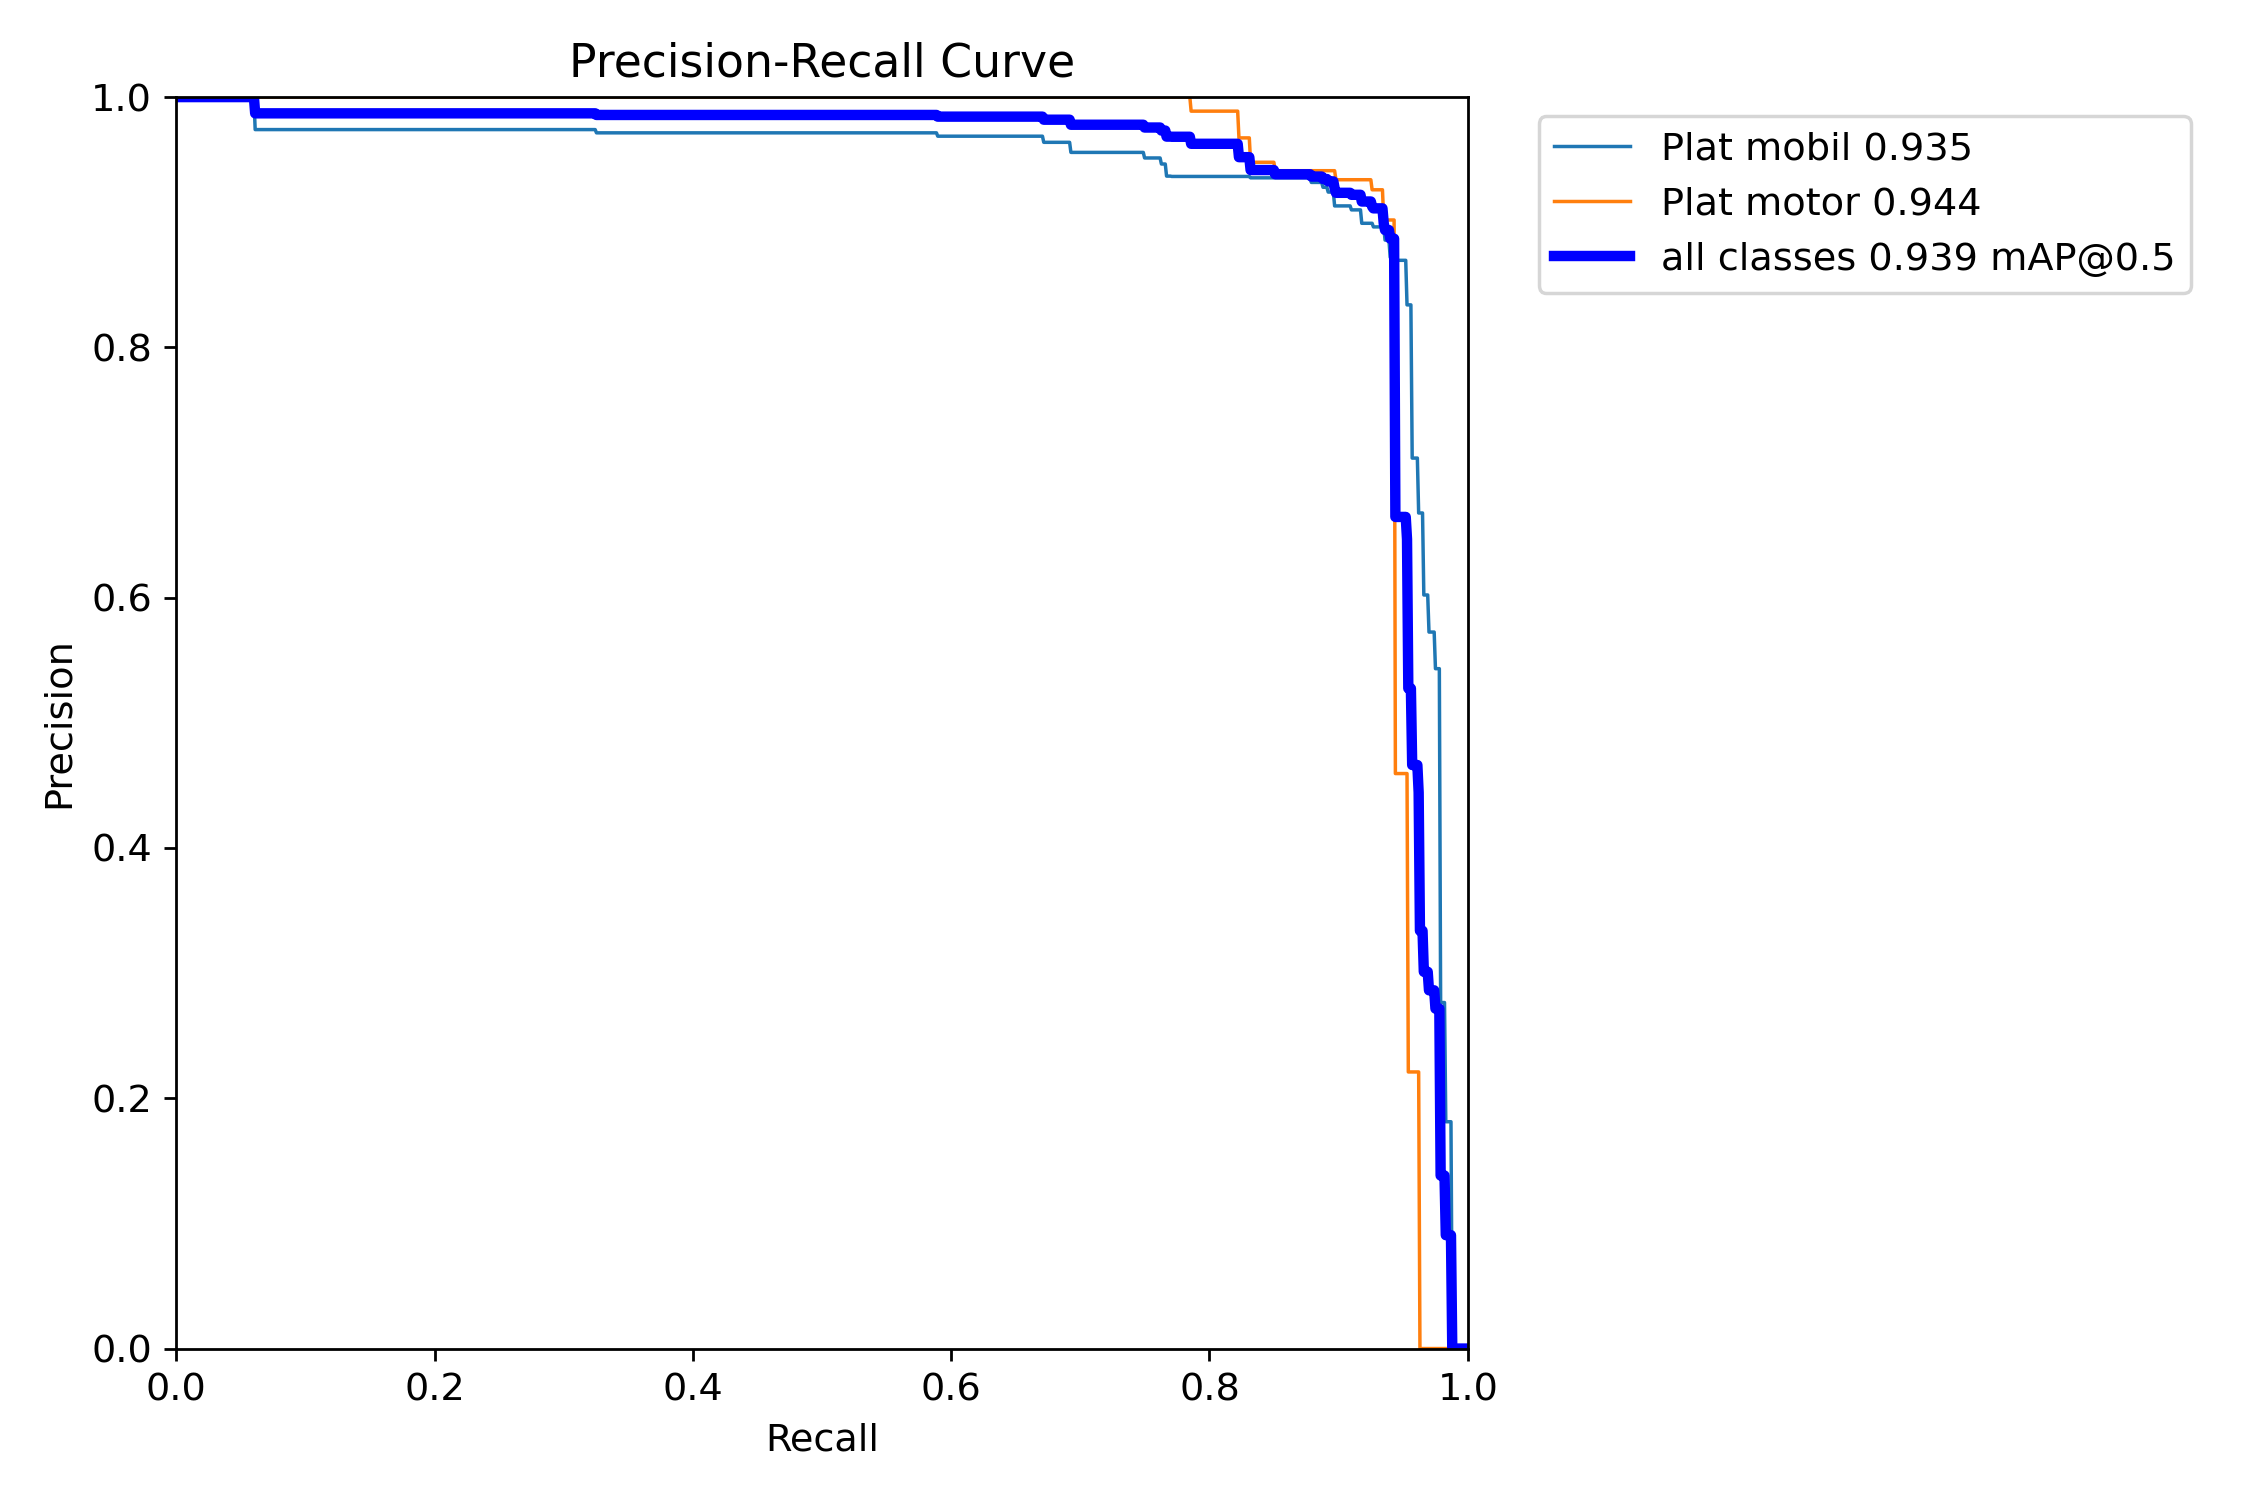

F1 CURVE


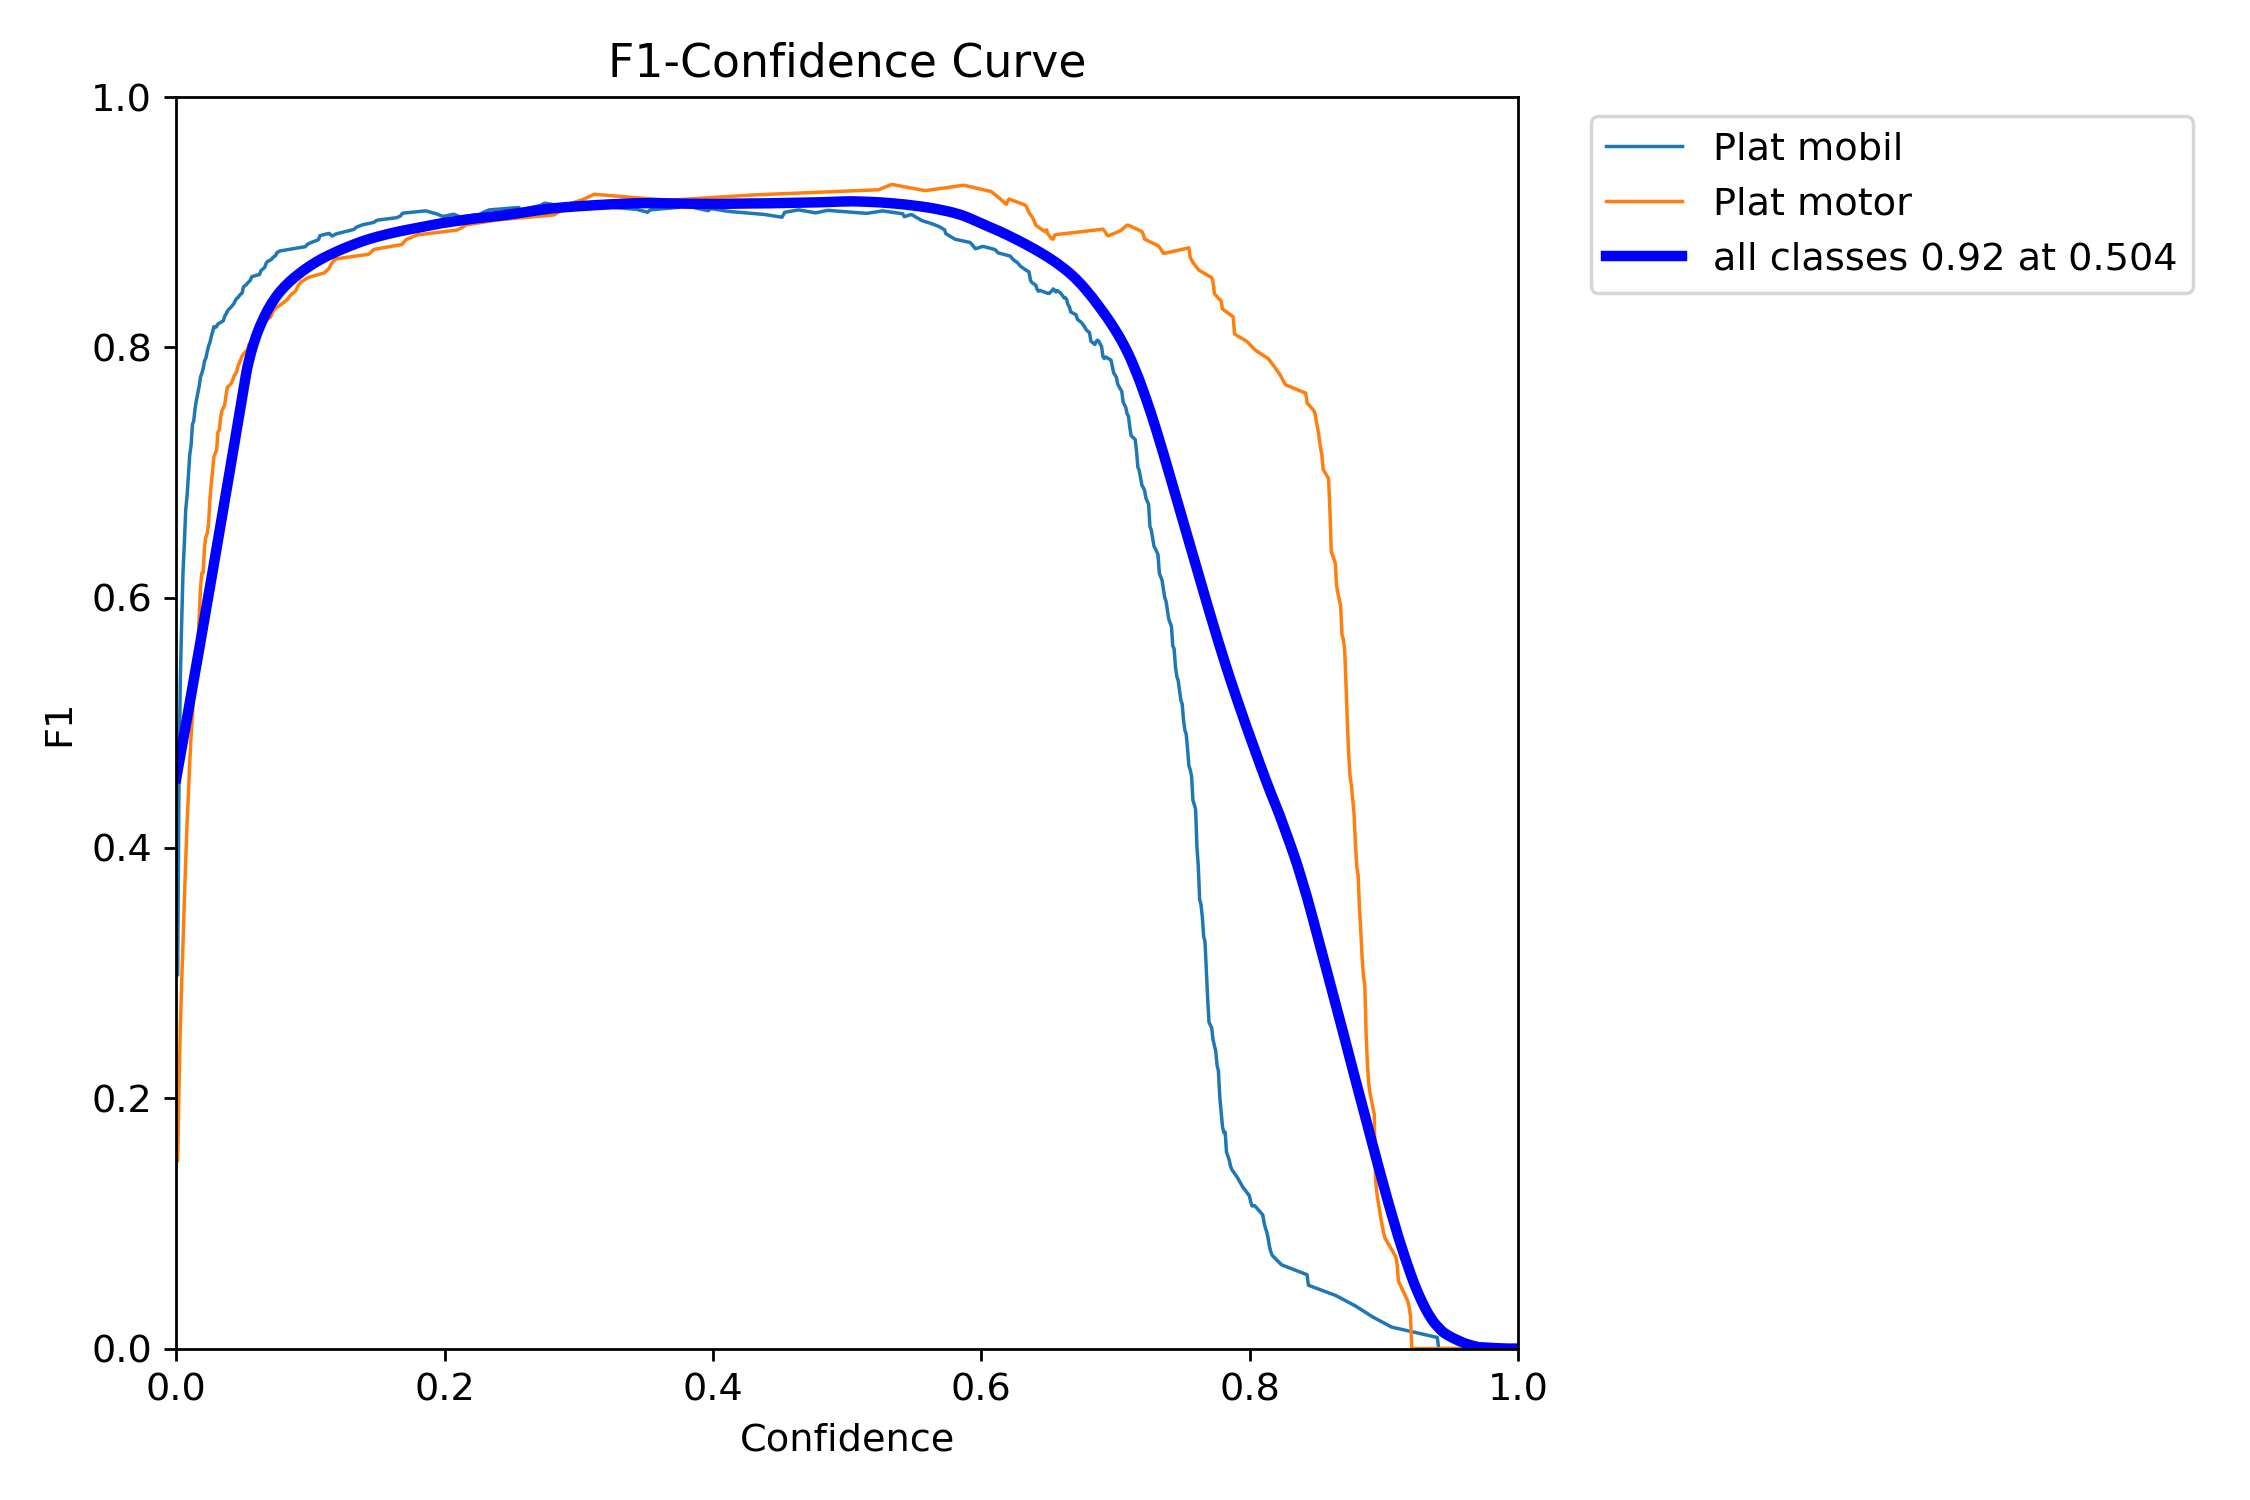

PRECISION CURVE


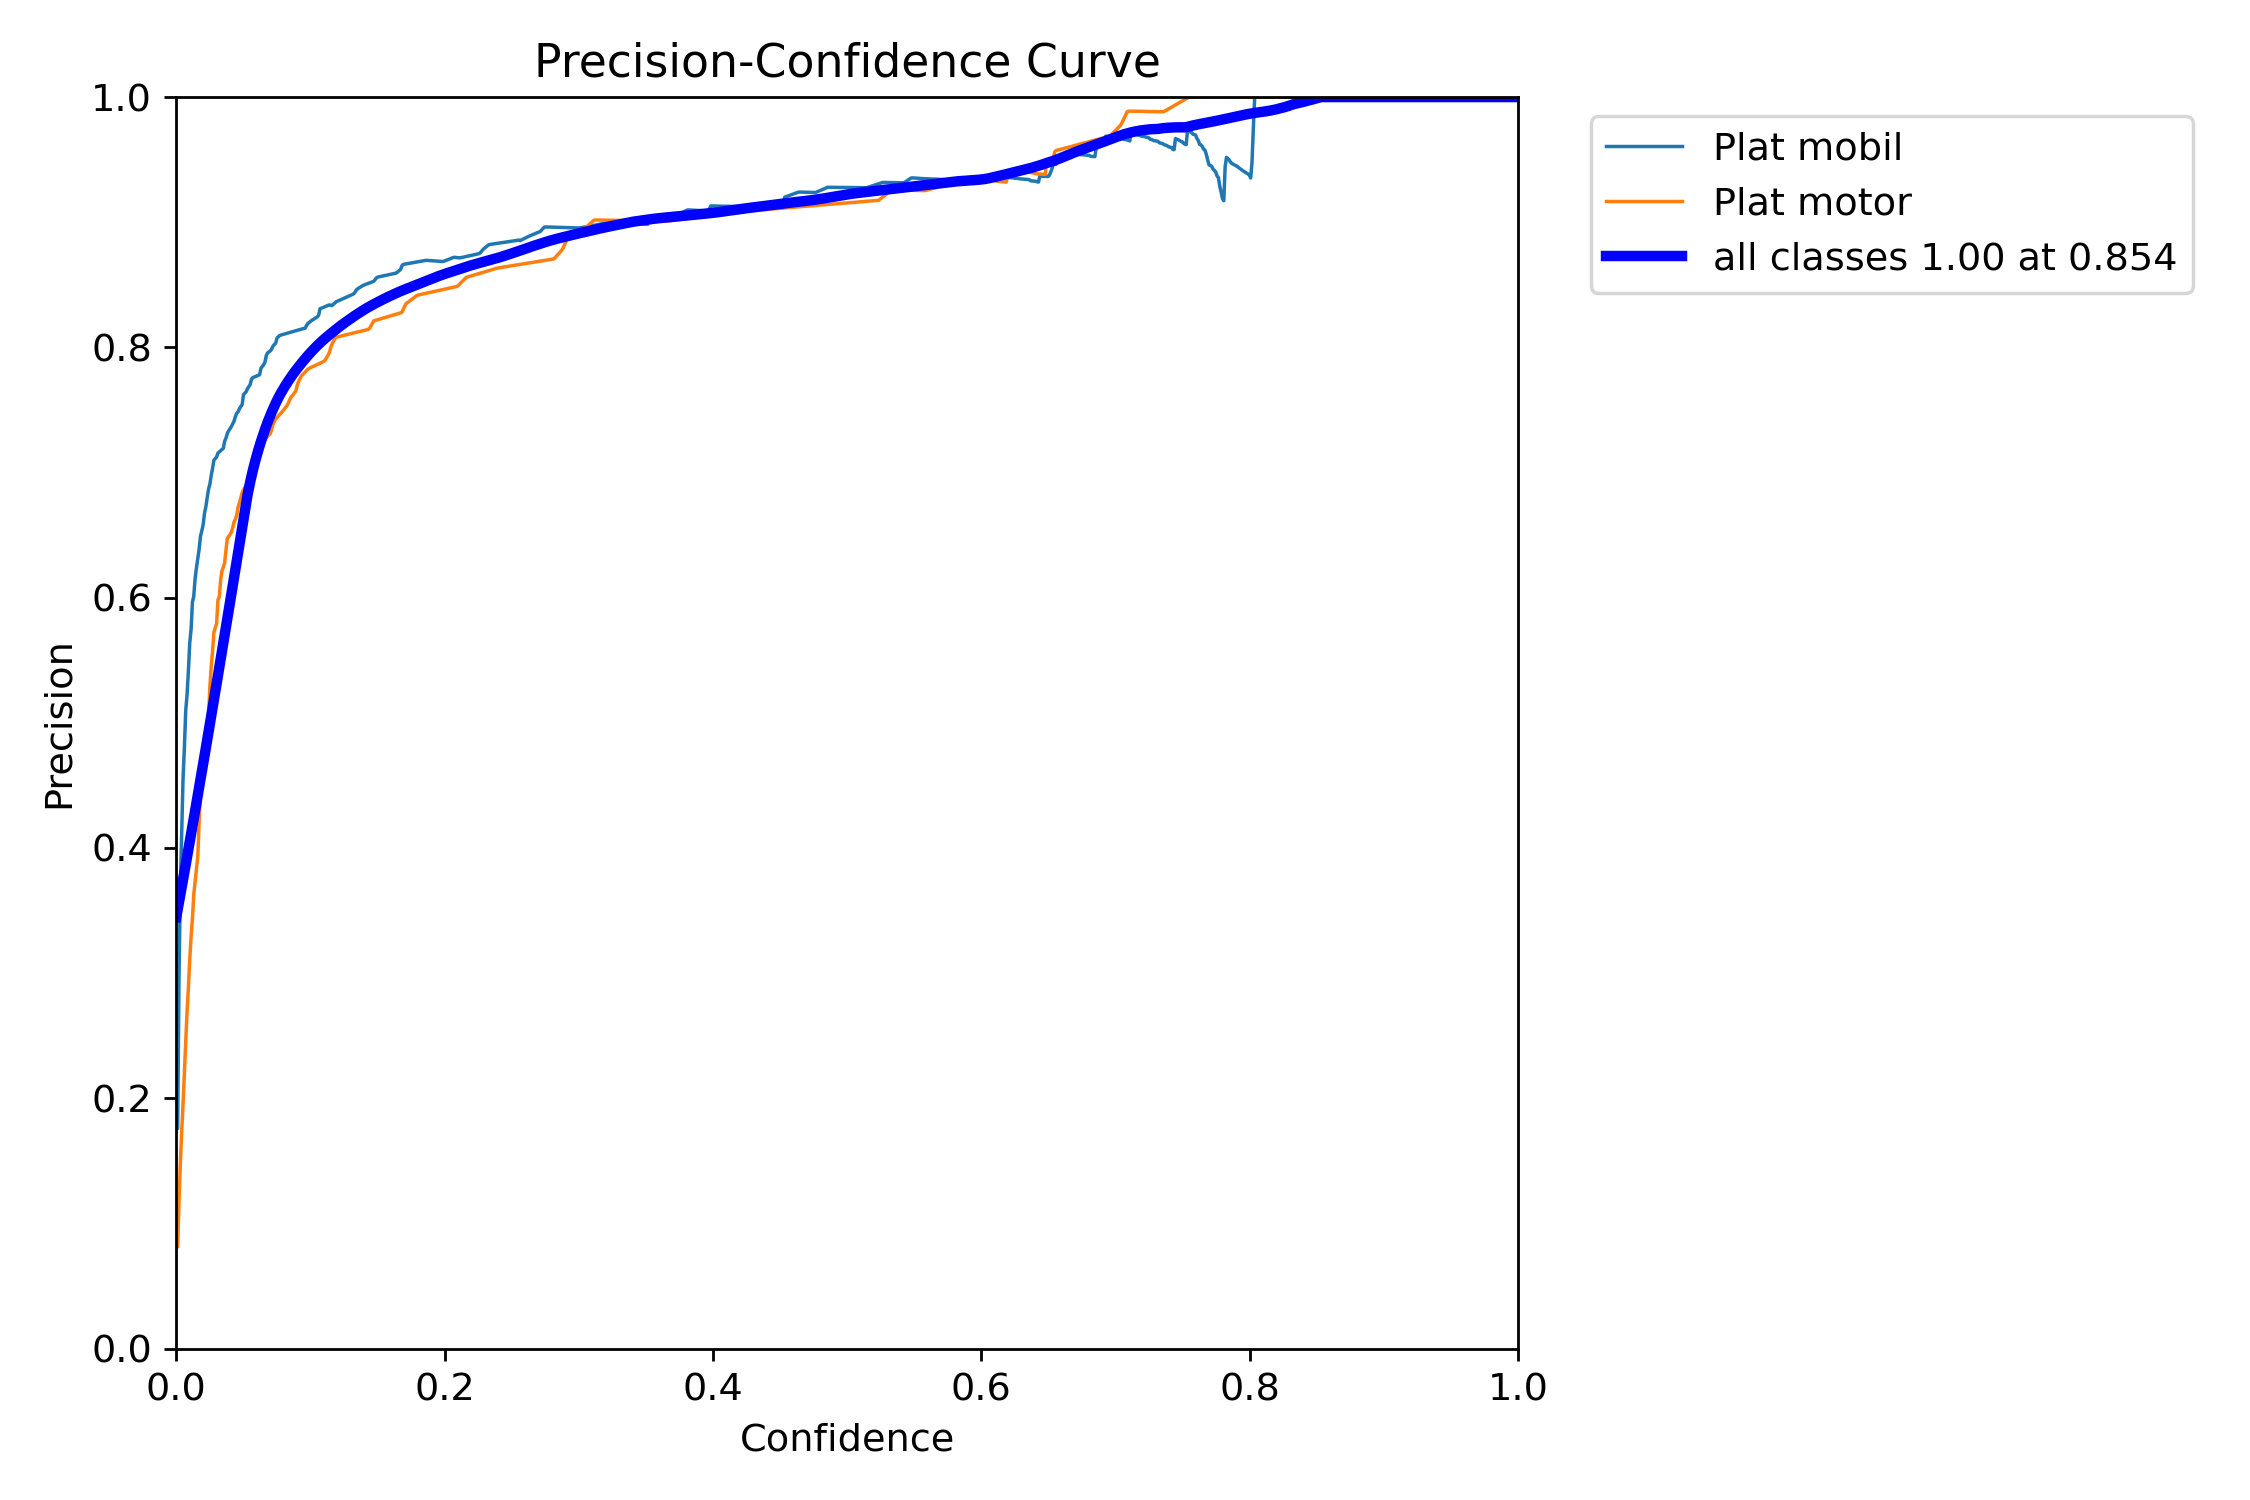

RECALL CURVE


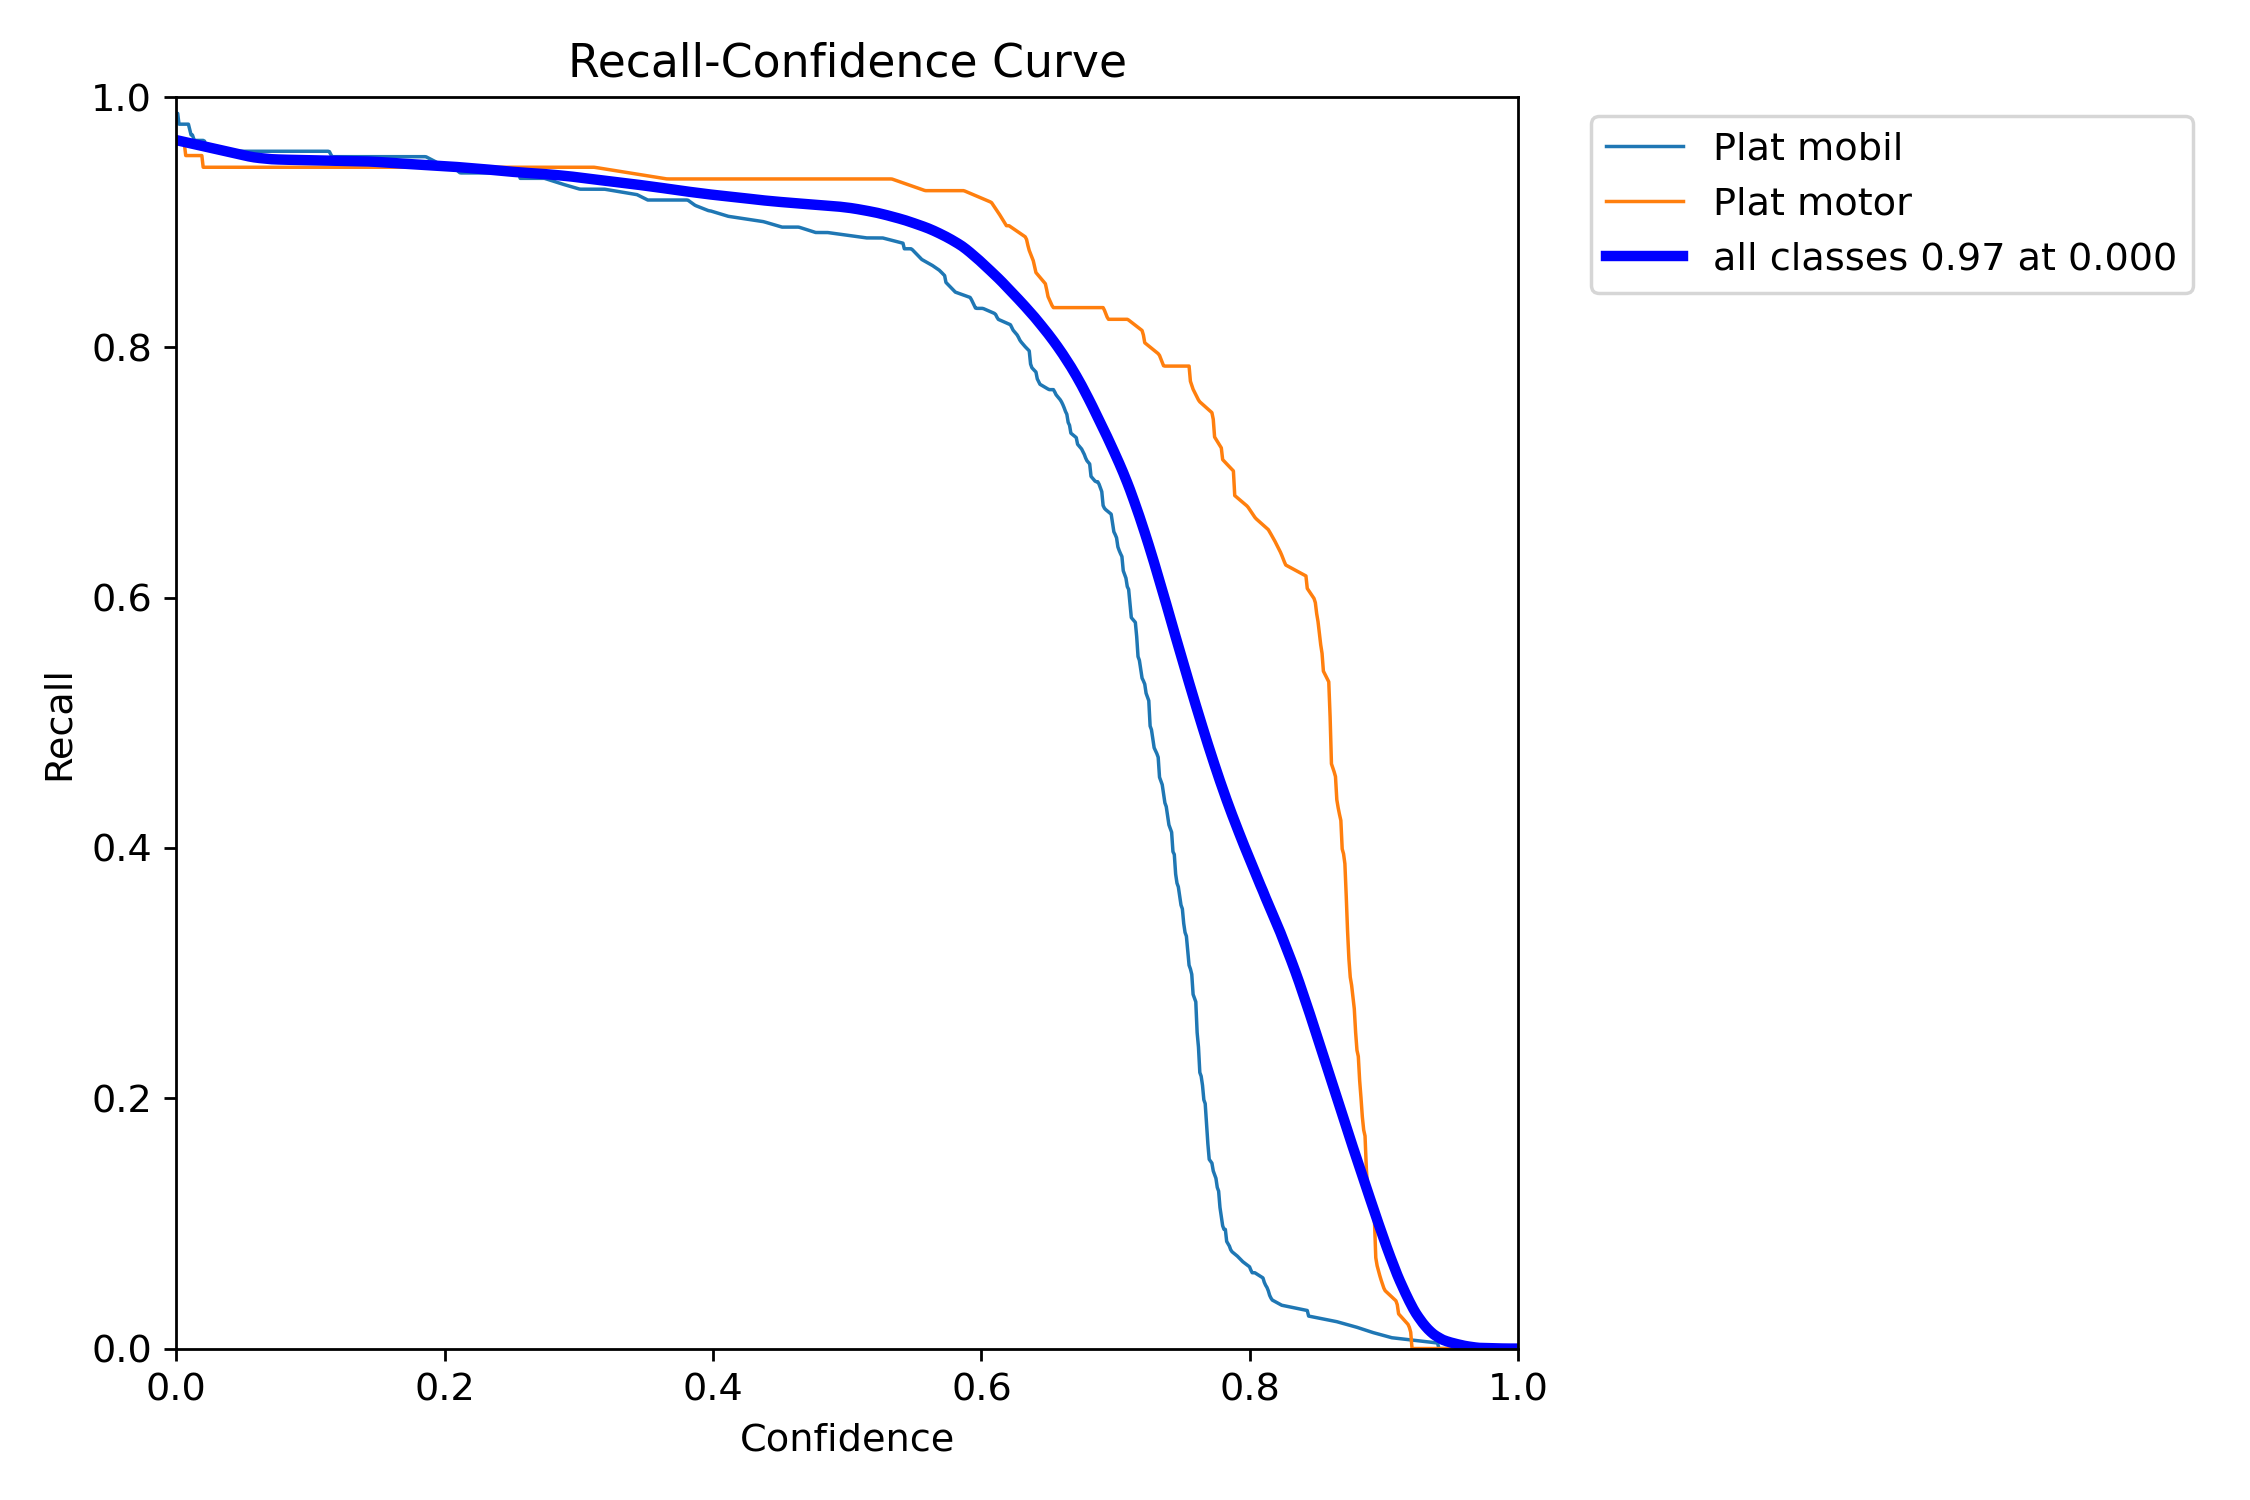

In [21]:
from IPython.display import Image, display

print("RESULTS")
display(Image('/content/runs/detect/train/results.png'))

print("CONFUSION MATRIX")
display(Image('/content/runs/detect/train/confusion_matrix.png'))

print("PRECISION-RECALL CURVE")
display(Image('/content/runs/detect/train/BoxPR_curve.png'))

print("F1 CURVE")
display(Image('/content/runs/detect/train/BoxF1_curve.png'))

print("PRECISION CURVE")
display(Image('/content/runs/detect/train/BoxP_curve.png'))

print("RECALL CURVE")
display(Image('/content/runs/detect/train/BoxR_curve.png'))

In [113]:
!pip install easyocr -q

In [120]:
import cv2
import easyocr
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files

In [121]:
MODEL_PATH = "/content/runs/detect/train/weights/best.pt"

model = YOLO(MODEL_PATH)

print("Model berhasil dimuat")

Model berhasil dimuat


In [122]:
uploaded = files.upload()

Saving plat_mobil_jkt.jpg to plat_mobil_jkt (1).jpg


In [123]:
image_path = list(uploaded.keys())[0]

results = model(
    image_path,
    save=True,
    conf=0.25
)

print("Deteksi selesai")


image 1/1 /content/plat_mobil_jkt (1).jpg: 480x640 1 Plat motor, 9.6ms
Speed: 2.0ms preprocess, 9.6ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict
Deteksi selesai


In [124]:
import os
from IPython.display import Image, display

predict_folder = "/content/runs/detect/predict"

files_pred = os.listdir(predict_folder)

print(files_pred)

['plat_mobil_jkt (1).jpg']


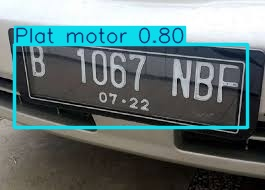

In [126]:
display(Image(
    f"/content/runs/detect/predict/{files_pred[0]}"
))

In [127]:
reader = easyocr.Reader(['en'])


0: 480x640 1 Plat motor, 9.3ms
Speed: 2.3ms preprocess, 9.3ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)


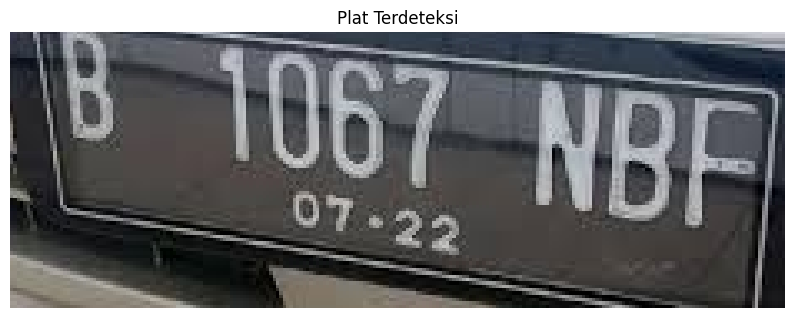

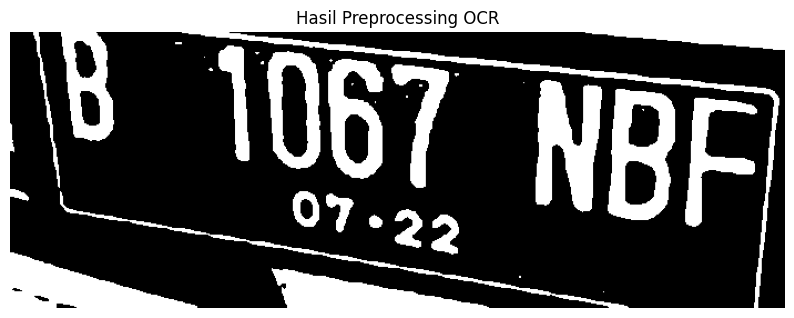

HASIL DETEKSI PLAT
Confidence : 80.45 %
Nomor Plat : B NBF 1067 07022


In [128]:
import cv2
import easyocr
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ==========================================
# LOAD MODEL
# ==========================================

model = YOLO("/content/runs/detect/train/weights/best.pt")

# ==========================================
# LOAD OCR
# ==========================================

reader = easyocr.Reader(['en'])

# ==========================================
# PILIH GAMBAR
# ==========================================

image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)

# ==========================================
# DETEKSI PLAT
# ==========================================

results = model(img)

# ==========================================
# PROSES SETIAP PLAT YANG TERDETEKSI
# ==========================================

for r in results:

    boxes = r.boxes.xyxy.cpu().numpy()
    confs = r.boxes.conf.cpu().numpy()

    for box, conf in zip(boxes, confs):

        x1, y1, x2, y2 = map(int, box)

        # Crop area plat
        crop = img[y1:y2, x1:x2]

        # ==================================
        # TAMPILKAN HASIL CROP
        # ==================================

        plt.figure(figsize=(10,4))
        plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        plt.title("Plat Terdeteksi")
        plt.axis("off")
        plt.show()

        # ==================================
        # PREPROCESSING OCR
        # ==================================

        gray = cv2.cvtColor(
            crop,
            cv2.COLOR_BGR2GRAY
        )

        gray = cv2.resize(
            gray,
            None,
            fx=3,
            fy=3,
            interpolation=cv2.INTER_CUBIC
        )

        gray = cv2.GaussianBlur(
            gray,
            (3,3),
            0
        )

        _, thresh = cv2.threshold(
            gray,
            0,
            255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

        # ==================================
        # TAMPILKAN HASIL PREPROCESSING
        # ==================================

        plt.figure(figsize=(10,4))
        plt.imshow(thresh, cmap='gray')
        plt.title("Hasil Preprocessing OCR")
        plt.axis("off")
        plt.show()

        # ==================================
        # OCR
        # ==================================

        ocr_result = reader.readtext(
        gray,
        allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789',
        detail=0
        )

        nomor_plat = " ".join(ocr_result)

        # ==================================
        # OUTPUT
        # ==================================

        print("="*50)
        print("HASIL DETEKSI PLAT")
        print("="*50)

        print(
            "Confidence :",
            round(float(conf)*100,2),
            "%"
        )

        print(
            "Nomor Plat :",
            nomor_plat
        )

        print("="*50)